# Phase 6: Error Analysis and Threshold Review

In this phase we inspect the best model from Phase 5, connect predictions back to image paths, review mistakes, and test whether a different tumor-probability threshold would improve precision/recall balance.

This phase does not retrain any model. It uses saved prediction CSV files from Phases 4 and 5.

## 1. Setup

Import project utilities and define paths. Finds the project root, loads class names, and points to the Phase 5 comparison table.

In [1]:
import csv
import sys
from pathlib import Path

from IPython.display import display
from PIL import Image, ImageDraw

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from spectiqai.data import LABEL_TO_CLASS, load_split_csv
from spectiqai.evaluation import binary_classification_metrics

RESULTS_DIR = PROJECT_ROOT / "results"
SPLIT_CSV_PATH = RESULTS_DIR / "dataset_splits.csv"
COMPARISON_PATH = RESULTS_DIR / "phase5_model_comparison.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Comparison path: {COMPARISON_PATH}")
print(f"Comparison exists: {COMPARISON_PATH.exists()}")

Project root: c:\Users\smart\Coding World\SpectiqAI
Comparison path: c:\Users\smart\Coding World\SpectiqAI\results\phase5_model_comparison.csv
Comparison exists: True


## 2. Select the Best Available Model

Choose the model with the highest F1 score from Phase 5. Reads the comparison CSV and sorts models by F1 score.

In [2]:
with COMPARISON_PATH.open("r", newline="", encoding="utf-8") as csv_file:
    comparison_rows = list(csv.DictReader(csv_file))

for row in comparison_rows:
    for key in ["accuracy", "precision", "recall", "f1_score"]:
        row[key] = float(row[key])

comparison_rows = sorted(comparison_rows, key=lambda row: row["f1_score"], reverse=True)
best_model = comparison_rows[0]["model"]

print("Model ranking:")
for row in comparison_rows:
    print(
        f"{row['model']}: accuracy={row['accuracy']:.4f}, "
        f"precision={row['precision']:.4f}, recall={row['recall']:.4f}, f1={row['f1_score']:.4f}"
    )

print(f"\nSelected model for error analysis: {best_model}")

Model ranking:
simple_cnn: accuracy=0.9893, precision=0.9791, recall=1.0000, f1=0.9894
resnet50: accuracy=0.7047, precision=0.8139, recall=0.5307, f1=0.6425
efficientnet_b0: accuracy=0.5847, precision=0.7414, recall=0.2600, f1=0.3850

Selected model for error analysis: simple_cnn


## 3. Attach Predictions to Image Paths

Make the predictions inspectable by connecting each row to its test image path. Loads the Phase 2 test split, reads the selected model's prediction CSV, assigns error types, and saves a detailed error-analysis CSV.

In [3]:
prediction_path = RESULTS_DIR / f"{best_model}_test_predictions.csv"
if not prediction_path.exists():
    raise FileNotFoundError(f"Prediction file not found: {prediction_path}")

splits = load_split_csv(SPLIT_CSV_PATH, project_root=PROJECT_ROOT)
test_records = splits["test"]

with prediction_path.open("r", newline="", encoding="utf-8") as csv_file:
    prediction_rows = list(csv.DictReader(csv_file))

if len(prediction_rows) != len(test_records):
    raise ValueError(
        f"Prediction rows ({len(prediction_rows)}) do not match test records ({len(test_records)}). "
        "Rerun evaluation on the full test set before doing final error analysis."
    )

analysis_rows = []
for record, prediction in zip(test_records, prediction_rows):
    true_label = int(prediction["true_label"])
    predicted_label = int(prediction["predicted_label"])
    tumor_probability = float(prediction["tumor_probability"])

    if true_label == predicted_label:
        error_type = "correct"
    elif true_label == 0 and predicted_label == 1:
        error_type = "false_positive"
    else:
        error_type = "false_negative"

    confidence = tumor_probability if predicted_label == 1 else 1.0 - tumor_probability
    analysis_rows.append({
        "path": str(record.path.relative_to(PROJECT_ROOT)),
        "true_label": true_label,
        "true_class": LABEL_TO_CLASS[true_label],
        "predicted_label": predicted_label,
        "predicted_class": LABEL_TO_CLASS[predicted_label],
        "tumor_probability": tumor_probability,
        "prediction_confidence": confidence,
        "error_type": error_type,
    })

analysis_path = RESULTS_DIR / f"{best_model}_error_analysis.csv"
with analysis_path.open("w", newline="", encoding="utf-8") as csv_file:
    fieldnames = list(analysis_rows[0].keys())
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(analysis_rows)

error_counts = {}
for row in analysis_rows:
    error_counts[row["error_type"]] = error_counts.get(row["error_type"], 0) + 1

print(f"Prediction file: {prediction_path}")
print(f"Saved analysis: {analysis_path}")
print(f"Error counts: {error_counts}")

Prediction file: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_test_predictions.csv
Saved analysis: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_error_analysis.csv
Error counts: {'correct': 1484, 'false_positive': 16}


## 4. Visualize the Highest-Confidence Mistakes

Inspect the mistakes the model made most confidently. Selects the top false positives and false negatives by prediction confidence and saves a contact sheet.

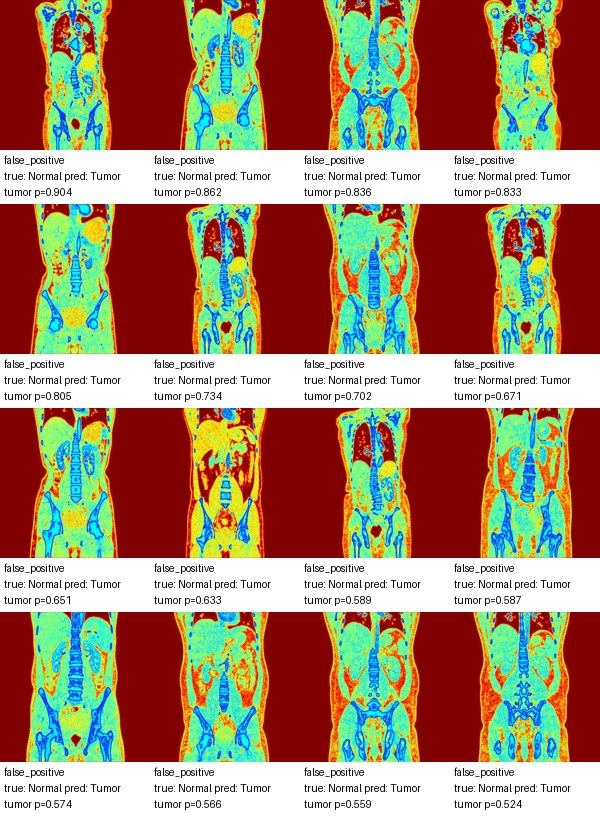

Saved error grid: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_error_examples.png


In [4]:
def create_error_grid(rows, output_path, max_examples=16, thumb_size=150):
    selected_rows = sorted(
        [row for row in rows if row["error_type"] != "correct"],
        key=lambda row: float(row["prediction_confidence"]),
        reverse=True,
    )[:max_examples]

    if not selected_rows:
        print("No errors found; skipping error grid.")
        return None

    columns = 4
    label_height = 54
    cell_width = thumb_size
    cell_height = thumb_size + label_height
    rows_count = (len(selected_rows) + columns - 1) // columns

    image = Image.new("RGB", (columns * cell_width, rows_count * cell_height), "white")
    draw = ImageDraw.Draw(image)

    for index, row in enumerate(selected_rows):
        column = index % columns
        grid_row = index // columns
        x = column * cell_width
        y = grid_row * cell_height

        image_path = PROJECT_ROOT / row["path"]
        with Image.open(image_path) as source_image:
            source_image = source_image.convert("RGB")
            source_image.thumbnail((thumb_size, thumb_size))
            paste_x = x + (thumb_size - source_image.width) // 2
            paste_y = y + (thumb_size - source_image.height) // 2
            image.paste(source_image, (paste_x, paste_y))

        text_y = y + thumb_size + 4
        draw.text((x + 4, text_y), row["error_type"], fill="black")
        draw.text((x + 4, text_y + 16), f"true: {row['true_class']} pred: {row['predicted_class']}", fill="black")
        draw.text((x + 4, text_y + 32), f"tumor p={float(row['tumor_probability']):.3f}", fill="black")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    image.save(output_path)
    return image

error_grid_path = RESULTS_DIR / f"{best_model}_error_examples.png"
error_grid = create_error_grid(analysis_rows, error_grid_path)
if error_grid is not None:
    display(error_grid)
    print(f"Saved error grid: {error_grid_path}")

## 5. Review Tumor-Probability Thresholds

See whether a threshold other than 0.50 would improve the precision/recall tradeoff. Recalculates metrics at thresholds from 0.10 to 0.90 and saves the table.

In [5]:
true_labels = [int(row["true_label"]) for row in analysis_rows]
tumor_probabilities = [float(row["tumor_probability"]) for row in analysis_rows]
threshold_rows = []

for step in range(1, 10):
    threshold = step / 10
    predicted_labels = [1 if probability >= threshold else 0 for probability in tumor_probabilities]
    metrics = binary_classification_metrics(true_labels, predicted_labels)
    threshold_rows.append({"threshold": threshold, **metrics})

threshold_rows = sorted(threshold_rows, key=lambda row: row["f1_score"], reverse=True)
threshold_path = RESULTS_DIR / f"{best_model}_threshold_review.csv"

with threshold_path.open("w", newline="", encoding="utf-8") as csv_file:
    fieldnames = list(threshold_rows[0].keys())
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(threshold_rows)

for row in threshold_rows:
    print(
        f"threshold={row['threshold']:.1f}: accuracy={row['accuracy']:.4f}, "
        f"precision={row['precision']:.4f}, recall={row['recall']:.4f}, f1={row['f1_score']:.4f}"
    )

print(f"Saved threshold review: {threshold_path}")

threshold=0.9: accuracy=0.9987, precision=0.9987, recall=0.9987, f1=0.9987
threshold=0.8: accuracy=0.9967, precision=0.9934, recall=1.0000, f1=0.9967
threshold=0.7: accuracy=0.9953, precision=0.9908, recall=1.0000, f1=0.9954
threshold=0.6: accuracy=0.9933, precision=0.9868, recall=1.0000, f1=0.9934
threshold=0.5: accuracy=0.9893, precision=0.9791, recall=1.0000, f1=0.9894
threshold=0.4: accuracy=0.9880, precision=0.9766, recall=1.0000, f1=0.9881
threshold=0.3: accuracy=0.9827, precision=0.9665, recall=1.0000, f1=0.9830
threshold=0.2: accuracy=0.9767, precision=0.9554, recall=1.0000, f1=0.9772
threshold=0.1: accuracy=0.9613, precision=0.9282, recall=1.0000, f1=0.9628
Saved threshold review: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_threshold_review.csv


## Phase 6 Completion Checklist

Verify that the following outputs have been generated:
- `{best_model}_error_analysis.csv` lists every test image with prediction details.
- `{best_model}_error_examples.png` shows the most confident mistakes.
- `{best_model}_threshold_review.csv` summarizes precision, recall, and F1 across thresholds.

Phase 6 identifies whether the main issue is false positives, false negatives, or calibration. Next step: choose an improvement path: threshold selection, transfer-model fine-tuning, stronger augmentation, or a validation-based model-selection protocol.